In [1]:
import os, sys, warnings, pickle
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import scipy.sparse as sp
from pathlib import Path
from plots import set_nature_style
set_nature_style()

warnings.filterwarnings("ignore", category=FutureWarning)
sys.path.insert(0, "..")

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_PROC    = Path("data/processed")
RESULTS_DIR  = Path("Results/stgp")
FIGURES_DIR  = Path("Figures/Fib_L")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CELLTYPE = "Fib"   # target cell type for this tutorial
adata_fib = sc.read_h5ad(DATA_PROC / f"{CELLTYPE}.h5ad")

In [2]:
adata_fib.obs['side'] = adata_fib.obs.ident.astype(str).str[-1]
adata_fib = adata_fib[adata_fib.obs['injury_time_days'] > 0].copy()
adata_fib = adata_fib[adata_fib.obs['side'] == 'L'].copy()
adata_fib.obs['age'] = adata_fib.obs['injury_time_days'].copy()
adata_fib

AnnData object with n_obs × n_vars = 75416 × 299
    obs: 'x_centroid', 'y_centroid', 'n_genes', 'n_counts', 'ident', 'region', 'celltype_plot', 'time', 'CN', 'injury_time_days', 'side', 'age'
    uns: 'CN_colors', 'celltype_plot_colors', 'ident_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [3]:
import time
from stgp.estimation import fit_pfactor
from stgp.kernels import (
    bandwidth_select_spatial, bandwidth_select_temporal,
    build_K_age, build_K_spa_list_from_stacked
)
from stgp.preprocessing import standardize_coords_list, log1p_norm_centered_list

OUT_DIR = RESULTS_DIR / "Fib_L"
OUT_DIR.mkdir(parents=True, exist_ok=True)
PKL_PATH = OUT_DIR / "stgp_result.pkl"

age_arr = adata_fib.obs["injury_time_days"]
groups  = adata_fib.obs["ident"].astype(str)
uniq, inv = np.unique(groups, return_inverse=True)
idx_per_group = [np.sort(np.where(inv == t)[0]) for t in range(len(uniq))]

adata_prep = adata_fib.copy()
sc.pp.scale(adata_prep)
Y_list = [adata_prep.X[ix] for ix in idx_per_group]
nlist    = np.array([len(ix) for ix in idx_per_group])
ages     = np.array([age_arr[ix[0]] for ix in idx_per_group])
sort_ord = np.argsort(ages);  ages = ages[sort_ord]
slices   = uniq.copy(); slices = slices[sort_ord]
nlist    = nlist[sort_ord]
Y_list   = [Y_list[i] for i in sort_ord]

/home/byual/.conda/envs/stGP/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [4]:
coords_list  = standardize_coords_list([adata_fib.obsm["spatial"][ix] for ix in idx_per_group])
coords_list = [coords_list[i] for i in sort_ord]
gamma_spa    = bandwidth_select_spatial(coords_list, frac=0.001, rho=0.6)
gamma_age    = bandwidth_select_temporal(ages, rho=np.exp(-1.5))
print(f"  gamma_spa = {gamma_spa:.4f}  |  gamma_age = {gamma_age:.4f}")

K_age     = build_K_age(ages, gamma_age, kernel="ar1", rho=0.7, standardize=True)
K_spa_list = build_K_spa_list_from_stacked(
    np.vstack(coords_list), nlist, gamma_spa, standardize=False, jitter=1e-6
)


  gamma_spa = 0.0777  |  gamma_age = 0.3904


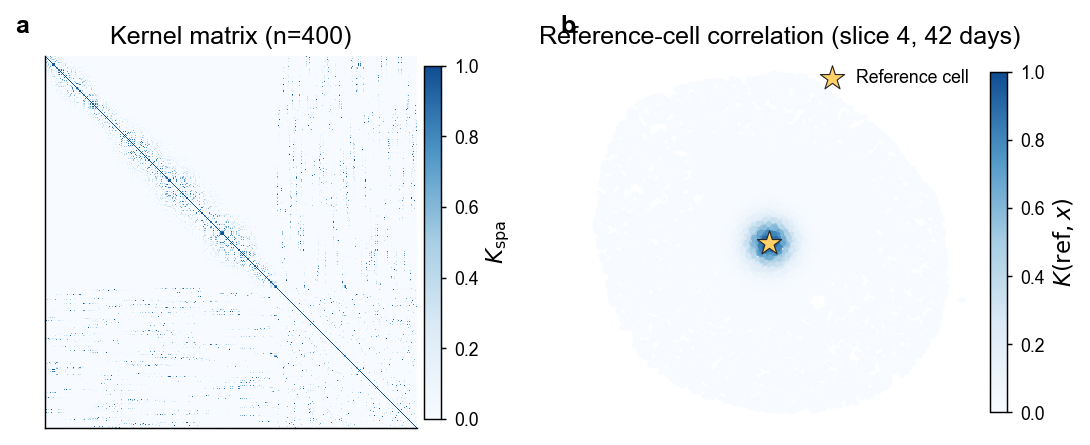

In [5]:
from plots import plot_spatial_kernel_corr_combined
fig = plot_spatial_kernel_corr_combined(
    adata=adata_fib,
    bandwidth=float(gamma_spa),
    slice_idx=5,
    out=FIGURES_DIR / "kernel_spatial.png",
)

[kernel] K_age (ar1)  well-conditioned  (cond=1.61e+01)  ->  Figures/Fib_L/kernel_age_fib.png


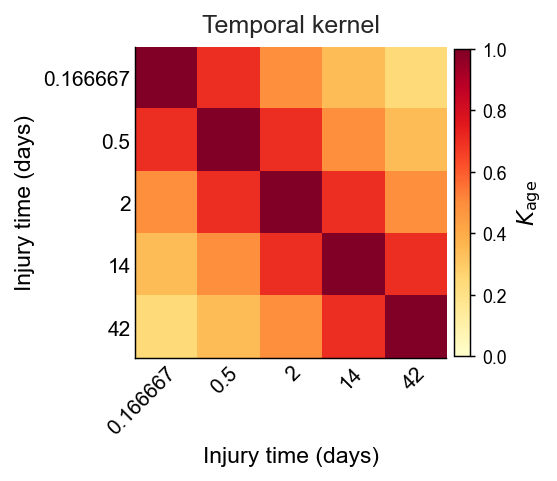

In [6]:
from plots import plot_kernel_age
fig = plot_kernel_age(
    K_age, ages, uniq_groups = "ident",
    kernel_type="ar1", celltype="fib",
    fig_dir=FIGURES_DIR,
)

In [7]:
res = fit_pfactor(
    Y_list=Y_list, Nlist=nlist, K_age=K_age, Kspa_list=K_spa_list,
    p=3, k=15, inner_rank1_tol=1e-4, random_state=0, verbose=1,
)

res["gamma_age"] = gamma_age; res["gamma_spa"] = gamma_spa
with open(PKL_PATH, "wb") as f:
    pickle.dump(res, f)
print(f"Saved: {PKL_PATH}")

[sweep=001] dW_rel=1.576e-01 dTheta_rel=2.830e-02 time=1.832e+01
[sweep=002] dW_rel=3.094e-02 dTheta_rel=7.860e-03 time=1.932e+01
[sweep=003] dW_rel=8.839e-03 dTheta_rel=2.170e-03 time=1.042e+01
[sweep=004] dW_rel=2.731e-03 dTheta_rel=6.411e-04 time=7.754e+00
Saved: Results/stgp/Fib_L/stgp_result.pkl


In [8]:
# ── Attach scores to AnnData & save ─────────────────────────────────────────
ADATA_PATH = OUT_DIR / "adata_with_scores.h5ad"

age_arr = pd.to_numeric(adata_fib.obs["age"], errors="coerce").to_numpy(float)
groups  = adata_fib.obs["ident"].astype(str).to_numpy()
uniq, inv = np.unique(groups, return_inverse=True)
idx_per_group = [np.sort(np.where(inv == t)[0]) for t in range(len(uniq))]

# Apply the same age-ascending sort used during model fitting
_ages_raw = np.array([age_arr[ix[0]] for ix in idx_per_group])
sort_ord      = np.argsort(_ages_raw)
idx_sorted    = [idx_per_group[i] for i in sort_ord]  
slices_sorted = uniq[sort_ord]                       
ages_sorted   = _ages_raw[sort_ord]                  

adata = adata_fib.copy()
all_idx = np.concatenate(idx_sorted)   # res["H"] rows follow this order
H_arr = np.empty_like(res["H"]);  H_arr[all_idx] = res["H"]
b_arr = np.empty_like(res["b"]);  b_arr[all_idx] = res["b"]
adata.obsm["X_stgp"]         = H_arr.astype(np.float32)
adata.obsm["X_stgp_spatial"] = b_arr.astype(np.float32)
adata.uns["stgp"] = dict(
    groups=slices_sorted.tolist(), ages=ages_sorted.tolist(),
    gamma_age=float(res["gamma_age"]), gamma_spa=float(res["gamma_spa"]),
    p_selected=res["W"].shape[0],
    alpha=np.asarray(res["alpha"]).tolist(),
    alpha_lower=np.asarray(res["alpha_lower"]).tolist(),
    alpha_upper=np.asarray(res["alpha_upper"]).tolist(),
    theta=np.asarray(res["theta"]).tolist(),
    sigma2e=float(res.get("sigma2e", np.nan)),
)
adata.write_h5ad(str(ADATA_PATH), compression="gzip")
print(f"Saved: {ADATA_PATH}")

# Also write W.csv for enrichment
p_sel = res["W"].shape[0]
W_df = pd.DataFrame(res["W"],
                    index=[f"stGP{j+1}" for j in range(p_sel)],
                    columns=adata.var_names.astype(str))
W_df.to_csv(OUT_DIR / "W.csv")

Saved: Results/stgp/Fib_L/adata_with_scores.h5ad


---
## 3. Loading Saved Results

The cells below reload all fitted outputs from disk so that the downstream
analysis (Section 4) can be run independently without re-fitting the model.
Skip this section if you are continuing directly from Section 2.


In [9]:
# ── Reload fitted outputs ──────────────────────────────────────────────────
ADATA_PATH = OUT_DIR / "adata_with_scores.h5ad"
adata      = sc.read_h5ad(str(ADATA_PATH))

W_df      = pd.read_csv(OUT_DIR / "W.csv", index_col=0)
stgp_info = adata.uns["stgp"]
p_sel     = stgp_info["p_selected"]
slices    = np.array(stgp_info["groups"])

W_df.index = [f"stGP{i+1}" for i in range(len(W_df))]
print(f"Loaded: {adata.n_obs} cells  |  {p_sel} programs  |  {len(slices)} slices")


Loaded: 75416 cells  |  3 programs  |  5 slices


---
## 4. Downstream Analysis

### 4.1 Gene Loadings (W matrix)

Each row of **W** is a non-negative weight vector over the measured genes.
Positive-weight genes define the molecular identity of each program; the
magnitude reflects the gene's contribution to that program.


In [10]:
W_df = pd.read_csv(OUT_DIR / "W.csv", index_col=0)
W_df.index = [f"stGP{i+1}" for i in range(len(W_df))]

print("Top 15 genes per program:")
for prog, row in W_df.iterrows():
    top = row[row > 0].sort_values(ascending=False).head(15)
    print(f"  {prog}: {', '.join(top.index.tolist())}")

Top 15 genes per program:
  stGP1: Akap12, Tagln, Fosl1, Spp1, Csf1, Serpine1, Krt20, Timp3, Umod, Plin2, Mcam, Cd24a, Havcr1, Calm1, Cd44
  stGP2: Cxcl12, Umod, Smoc2, Spon1, Slc12a1, Kcnd2, Ptger1, Sfrp1, Bmpr1b, Gpc6, Grem2, Adgrl3, Ano1, Sdc2, Cdkn1c
  stGP3: Cyp4b1, Cxcl12, Cyp2e1, Inmt, Mgp, Bmp6, Spink1, Cndp2, Agtr1a, Slc22a6, Acsm3, Hnf4a, Slc22a8, Acox1, Slc7a13


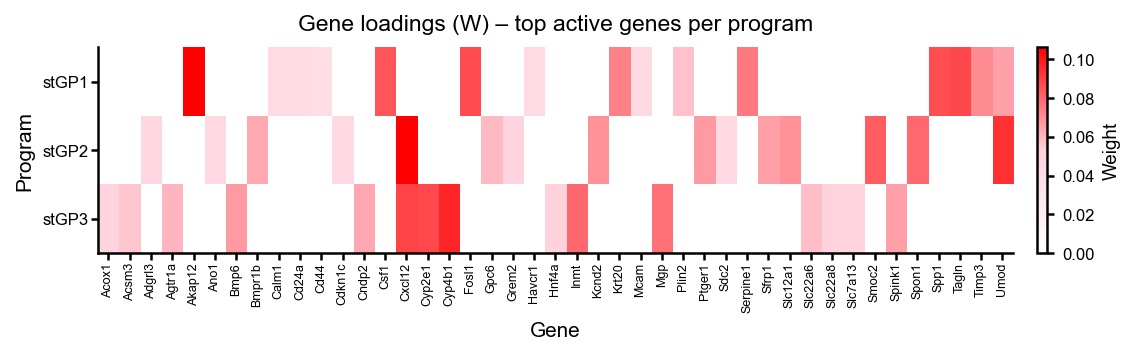

In [11]:
from plots import plot_W_program_heatmap

fig = plot_W_program_heatmap(
    W_df,
    title="Gene loadings (W) – top active genes per program",
    out=FIGURES_DIR / "W_heatmap.png",
    dpi=400,
)

### 4.2 Spatial Gene-Program Maps

The **spatial field b** captures the within-slice smooth variation of each program.
We tile all tissue sections ordered by donor age so any age-related spatial patterns
become visible.

In [12]:
from plots import plot_stgp_spatial_programs

scores_df = pd.DataFrame(
    adata.obsm["X_stgp_spatial"],
    index=adata.obs_names,
    columns=[f"stGP{j+1}" for j in range(p_sel)],
)

figs = plot_stgp_spatial_programs(
    stgp_adata=adata, scores=scores_df,
    celltype="Fibroblasts",
    ncols=4, fg_dot_size=5.0, dpi=300,
)
for j, fig in enumerate(figs):
    fig.savefig(FIGURES_DIR / f"spatial_stGP{j+1}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)
print(f"Saved {len(figs)} spatial program figures → {FIGURES_DIR}")

Saved 3 spatial program figures → Figures/Fib_L


### 4.4 Age Trajectories (α)

**α(t)** is the posterior mean age effect of each program — it quantifies how the
program amplitude changes across the human lifespan (15–87 yr).
The shaded band shows the 95% posterior credible interval.

Saved alpha trajectory figures → Figures/Fib_L


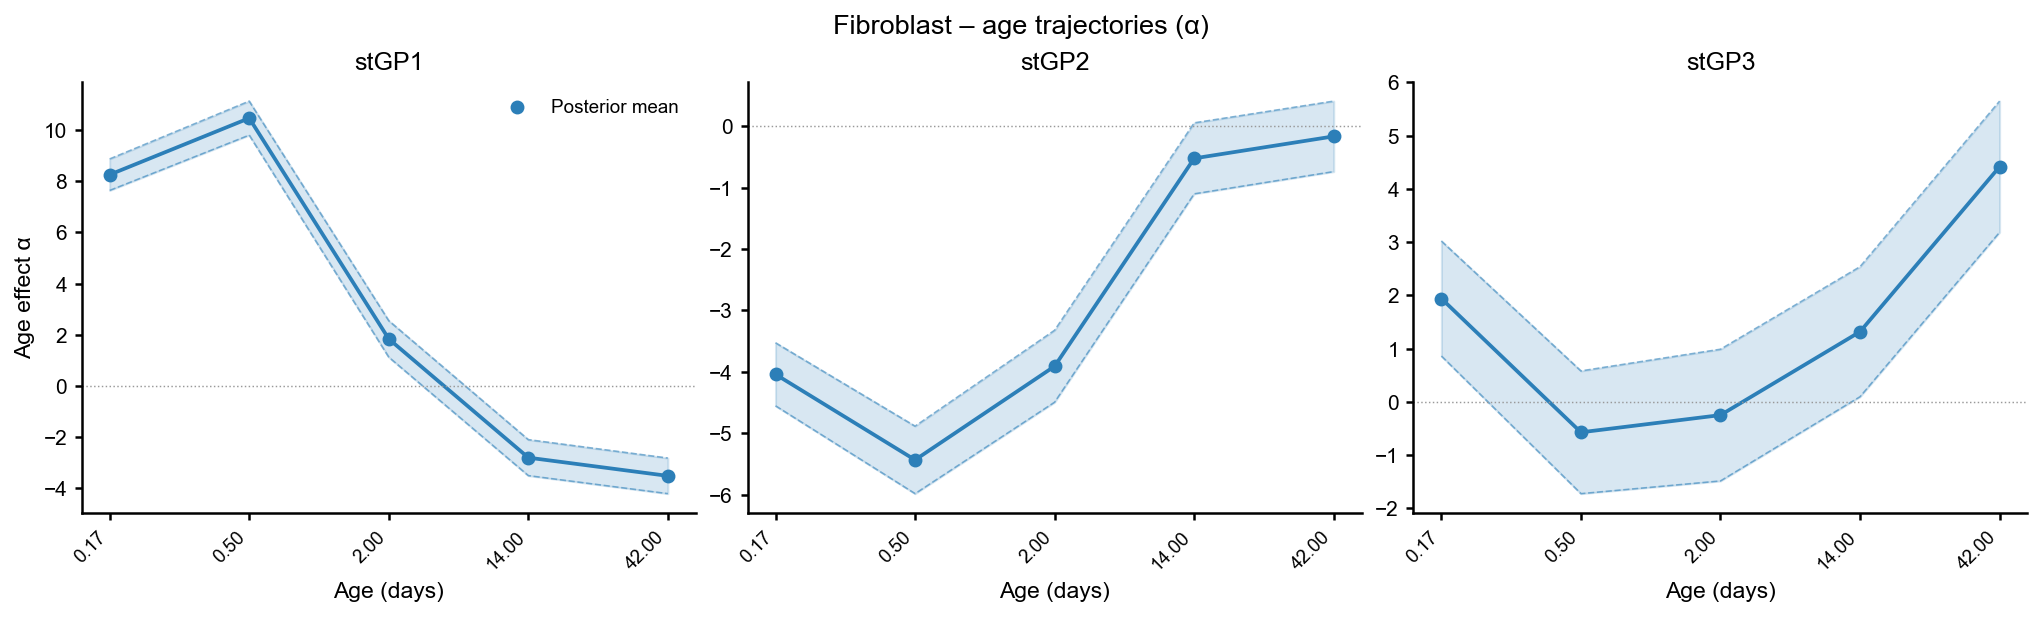

In [13]:
stgp_info   = adata.uns['stgp']
ages_slices = np.array(stgp_info['ages'])
alpha       = np.array(stgp_info['alpha'])        # (p, n_slices)
alpha_lower = np.array(stgp_info['alpha_lower'])
alpha_upper = np.array(stgp_info['alpha_upper'])

COLOR = '#2C7FB8'
fig, axes = plt.subplots(1, p_sel, figsize=(4.5 * p_sel, 4), constrained_layout=True)
for j, ax in enumerate(np.atleast_1d(axes)):
    order = np.argsort(ages_slices)
    t_idx = np.arange(len(order))  # 均匀分布的索引
    t_ages = ages_slices[order]     # 真实的年龄值
    a  = alpha[j][order]
    lo = alpha_lower[j][order]
    hi = alpha_upper[j][order]
    ax.fill_between(t_idx, lo, hi, alpha=0.18, color=COLOR)
    ax.plot(t_idx, lo, lw=0.8, ls='--', color=COLOR, alpha=0.55)
    ax.plot(t_idx, hi, lw=0.8, ls='--', color=COLOR, alpha=0.55)
    ax.plot(t_idx, a,  lw=1.8, color=COLOR)
    ax.scatter(t_idx, a, s=32, color=COLOR, zorder=3,
               label='Posterior mean' if j == 0 else '')
    ax.axhline(0, color='0.6', lw=0.7, ls=':')
    ax.set_title(f'stGP{j+1}', fontsize=12)
    ax.set_xticks(t_idx)
    ax.set_xticklabels([f'{age:.2f}' for age in t_ages], rotation=45, ha='right', fontsize=9)
    ax.set_xlabel('Age (days)')
    ax.set_ylabel('Age effect α' if j == 0 else '')
    if j == 0:
        ax.legend(fontsize=9)

fig.suptitle('Fibroblast – age trajectories (α)', fontsize=13)
fig.savefig(FIGURES_DIR / "alpha_trajectories.svg", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "alpha_trajectories.png", dpi=400, bbox_inches="tight")
print(f"Saved alpha trajectory figures → {FIGURES_DIR}")

### 4.5 GP Parameters (θ)

For each program, **θ = [amplitude, noise_fraction]** describes the relative strength of
the spatial GP component versus cell-intrinsic noise.
A high amplitude with low noise fraction indicates a strongly spatially structured program.

/tmp/ipykernel_3175089/4006084517.py:22: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.savefig(FIGURES_DIR / "theta_barplot.png", dpi=400, bbox_inches="tight")
/tmp/ipykernel_3175089/4006084517.py:22: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(FIGURES_DIR / "theta_barplot.png", dpi=400, bbox_inches="tight")
/home/byual/.conda/envs/stGP/lib/python3.11/site-packages/IPython/core/events.py:100: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  func(*args, **kwargs)
/home/byual/.conda/envs/stGP/lib/python3.11/site-packages/IPython/core/events.py:100: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  func(*args, **kwargs)
/home/byual/.conda/envs/stGP/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/home/byual/.conda/envs/stGP/lib/python3.11/site

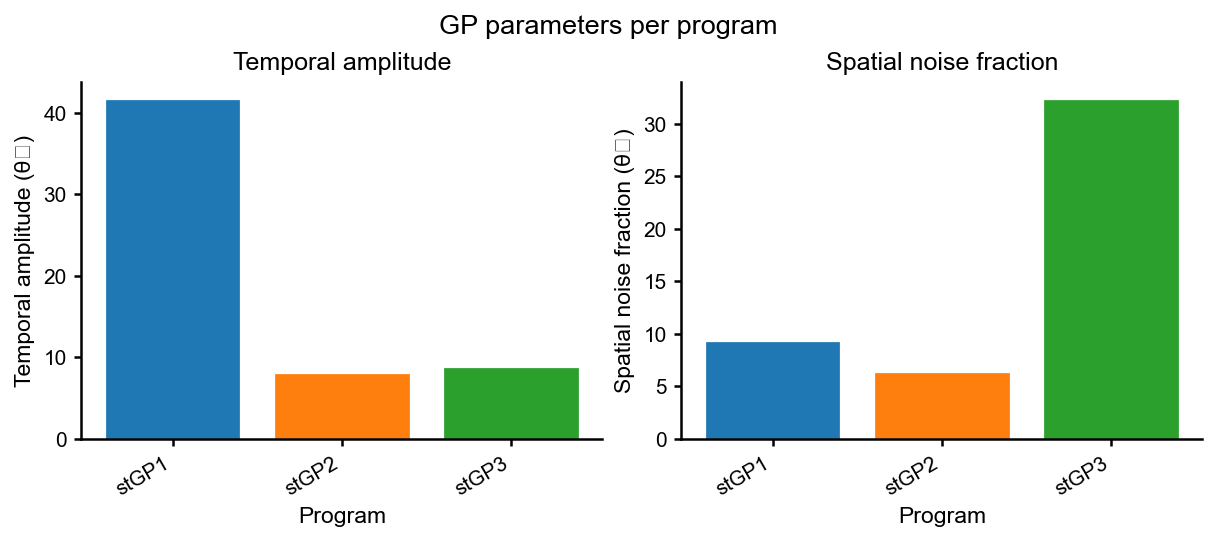

In [14]:
theta      = np.array(stgp_info['theta'])   # (p, 2): [amplitude, noise_frac]
prog_names = [f'stGP{j+1}' for j in range(p_sel)]
prog_colors = plt.cm.tab10.colors[:p_sel]

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), constrained_layout=True)

for j, (col, name) in enumerate(zip(prog_colors, prog_names)):
    axes[0].bar(j, theta[j, 0], color=col, edgecolor='white', linewidth=0.6)
    axes[1].bar(j, theta[j, 1], color=col, edgecolor='white', linewidth=0.6)

for ax in axes:
    ax.set_xticks(range(p_sel))
    ax.set_xticklabels(prog_names, rotation=30, ha='right')
    ax.set_xlabel('Program')

axes[0].set_ylabel('Temporal amplitude (θ₁)')
axes[0].set_title('Temporal amplitude')
axes[1].set_ylabel('Spatial noise fraction (θ₂)')
axes[1].set_title('Spatial noise fraction')

fig.suptitle('GP parameters per program', fontsize=13)
fig.savefig(FIGURES_DIR / "theta_barplot.png", dpi=400, bbox_inches="tight")

### 4.6 Spatial Visualisation of a Single Slice

We inspect one tissue slice in detail, showing the **spatial b field** of each program
(the smooth within-slice component).

Visualising slice: Day14L  (age 14 day, n=23035 cells)


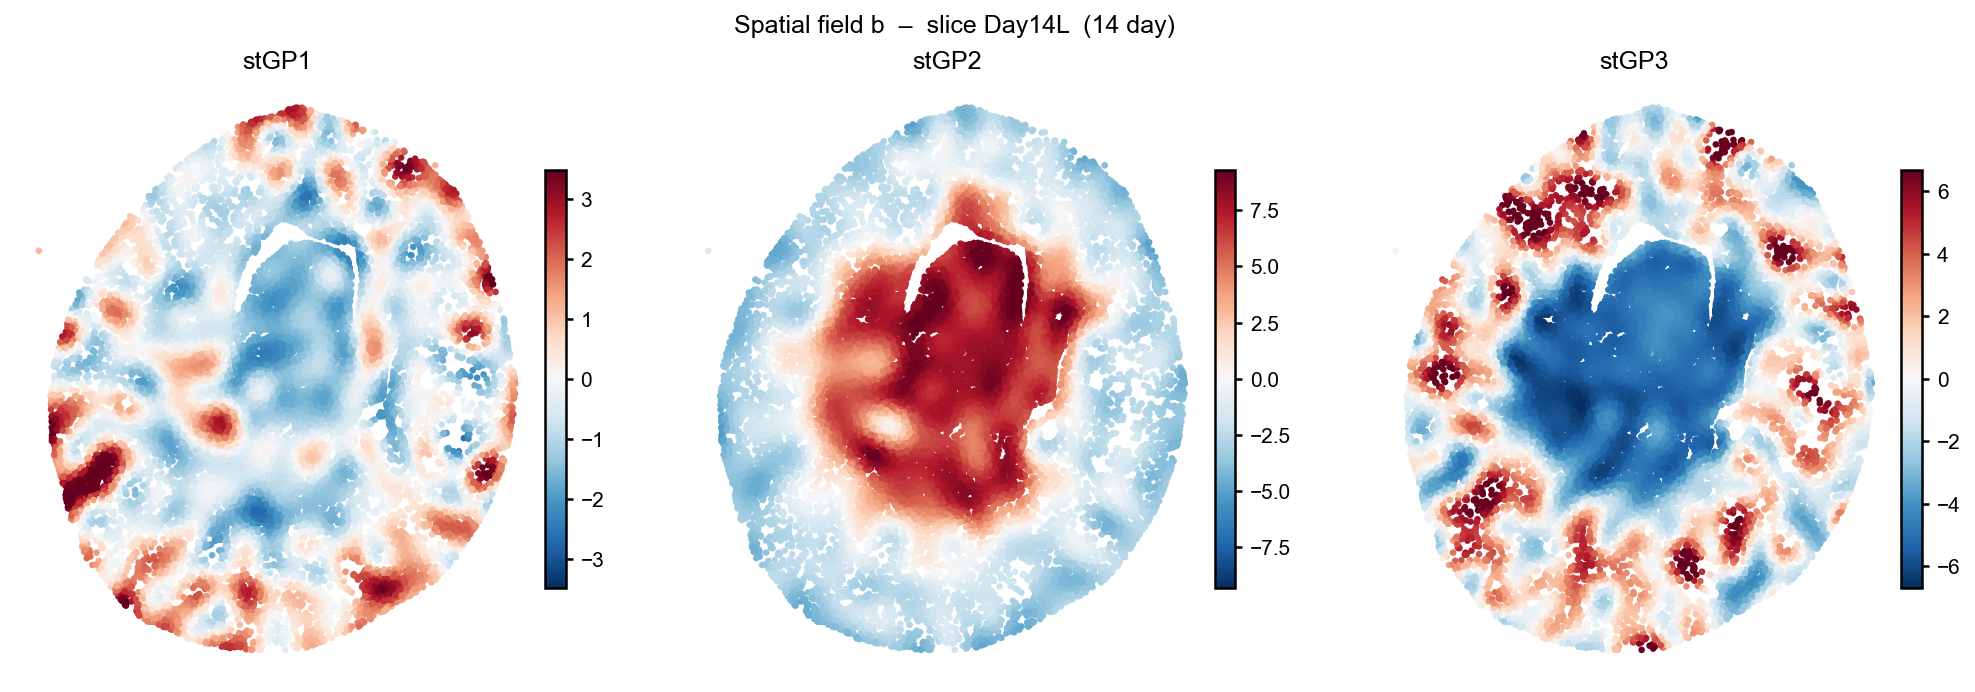

In [15]:
# Pick a mid-age slice
example_slice = 'Day14L'
sub     = adata[adata.obs['ident'] == example_slice].copy()
age_val = sub.obs['injury_time_days'].iloc[0]
print(f'Visualising slice: {example_slice}  (age {age_val:.0f} day, n={sub.n_obs} cells)')

fig, axes = plt.subplots(1, p_sel, figsize=(4.5 * p_sel, 4.5), constrained_layout=True)
b  = sub.obsm['X_stgp_spatial']
xy = np.asarray(sub.obsm['spatial'])
for j, ax in enumerate(np.atleast_1d(axes)):
    v99 = np.nanpercentile(np.abs(b[:, j]), 99)
    sc_ref = ax.scatter(xy[:, 0], xy[:, 1], c=b[:, j],
                        cmap='RdBu_r', vmin=-v99, vmax=v99,
                        s=10, linewidths=0, rasterized=True)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(f'stGP{j+1}')
    plt.colorbar(sc_ref, ax=ax, shrink=0.7, pad=0.01)

fig.suptitle(f'Spatial field b  –  slice {example_slice}  ({age_val:.0f} day)', fontsize=12)
fig.savefig(FIGURES_DIR / f"spatial_b_{example_slice}.png", dpi=400, bbox_inches="tight")